### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no : 7

1. Extract Sample document and apply following document preprocessing methods: Tokenization, POS
Tagging, stop words removal, Stemming and Lemmatization.
2. Create representation of documents by calculating Term Frequency and Inverse Document Frequency.

# NLP Preprocessing and TF-IDF Practical

This notebook demonstrates:
1. Tokenization -> break text into words 
2. POS Tagging -> identify word types (none , verd,etc )
3. Stopword Removal -> remove common words like is, the 
4. Stemming -> cut the words to root form (learning->learn)
5. Lemmatization -> conver words to meaningful form 
6. TF-IDF Representation -> find important words in documents

In [29]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer

In [46]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\OM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\OM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\OM\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\OM\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\OM\AppData\Roaming\nltk_data...
[nltk_dat

True

In [34]:
import pandas as pd

# Improved sample documents
documents = [
    "Natural language processing is very useful in text analysis.",
    "Machine learning improves automatically with more data.",
    "Data science is interesting and powerful for analysis.",
    "Deep learning is a part of machine learning.",
    "Natural language processing helps in understanding human language.",
    "Big data and data science are closely related fields.",
    "Artificial intelligence includes machine learning and deep learning.",
    "Text processing and natural language processing are important in NLP.",
    "Data analysis and visualization are key in data science.",
    "Machine learning models improve with training data."
]

df = pd.DataFrame({'document': documents})

df

,document
0,Natural language processing is very useful in ...
1,Machine learning improves automatically with m...
2,Data science is interesting and powerful for a...
3,Deep learning is a part of machine learning.
4,Natural language processing helps in understan...
5,Big data and data science are closely related ...
6,Artificial intelligence includes machine learn...
7,Text processing and natural language processin...
8,Data analysis and visualization are key in dat...
9,Machine learning models improve with training ...


In [35]:
# Text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['clean_text'] = df['document'].apply(clean_text)
df

,document,clean_text
0,Natural language processing is very useful in ...,natural language processing is very useful in ...
1,Machine learning improves automatically with m...,machine learning improves automatically with m...
2,Data science is interesting and powerful for a...,data science is interesting and powerful for a...
3,Deep learning is a part of machine learning.,deep learning is a part of machine learning
4,Natural language processing helps in understan...,natural language processing helps in understan...
5,Big data and data science are closely related ...,big data and data science are closely related ...
6,Artificial intelligence includes machine learn...,artificial intelligence includes machine learn...
7,Text processing and natural language processin...,text processing and natural language processin...
8,Data analysis and visualization are key in dat...,data analysis and visualization are key in dat...
9,Machine learning models improve with training ...,machine learning models improve with training ...


In [36]:
# Select sample document
sample_text = df['clean_text'][0]
sample_text

'natural language processing is very useful in text analysis'

In [37]:
# Tokenization
tokens = word_tokenize(sample_text)
tokens

['natural',
 'language',
 'processing',
 'is',
 'very',
 'useful',
 'in',
 'text',
 'analysis']

In [38]:
# POS Tagging
pos_tags = pos_tag(tokens)
pos_tags

[('natural', 'JJ'),
 ('language', 'NN'),
 ('processing', 'NN'),
 ('is', 'VBZ'),
 ('very', 'RB'),
 ('useful', 'JJ'),
 ('in', 'IN'),
 ('text', 'NN'),
 ('analysis', 'NN')]

In [39]:
# Stopword Removal
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]
filtered_tokens

['natural', 'language', 'processing', 'useful', 'text', 'analysis']

In [40]:
# Stemming
stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in filtered_tokens]
stemmed_words

['natur', 'languag', 'process', 'use', 'text', 'analysi']

In [41]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_tokens]
lemmatized_words

['natural', 'language', 'processing', 'useful', 'text', 'analysis']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Create TF-IDF Vectorizer (removes English stopwords)
vectorizer = TfidfVectorizer(stop_words='english')

# Convert text data into TF-IDF matrix / number
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])

# Get feature (word) names
feature_names = vectorizer.get_feature_names_out()

# Convert TF-IDF matrix into DataFrame for easy viewing
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# Display basic information
print('TF-IDF Matrix shape:', tfidf_matrix.shape)   # (rows, columns)
print('Top 10 terms:', feature_names[:10])          # first 10 words

# Show TF-IDF table
tfidf_df.head()

TF-IDF Matrix shape: (10, 32)
Top 10 terms: ['analysis' 'artificial' 'automatically' 'big' 'closely' 'data' 'deep'
 'fields' 'helps' 'human']


,analysis,artificial,automatically,big,closely,data,deep,fields,helps,human,...,nlp,powerful,processing,related,science,text,training,understanding,useful,visualization
0,0.374914,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.00000,0.374914,0.0,0.000000,0.428532,0.0,0.000000,0.504101,0.0
1,0.000000,0.0,0.556667,0.0,0.0,0.330561,0.000000,0.0,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
2,0.399896,0.0,0.000000,0.0,0.0,0.319291,0.000000,0.0,0.000000,0.000000,...,0.0,0.53769,0.000000,0.0,0.399896,0.000000,0.0,0.000000,0.000000,0.0
3,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.498437,0.0,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.397816,0.397816,...,0.0,0.00000,0.295868,0.0,0.000000,0.000000,0.0,0.397816,0.000000,0.0


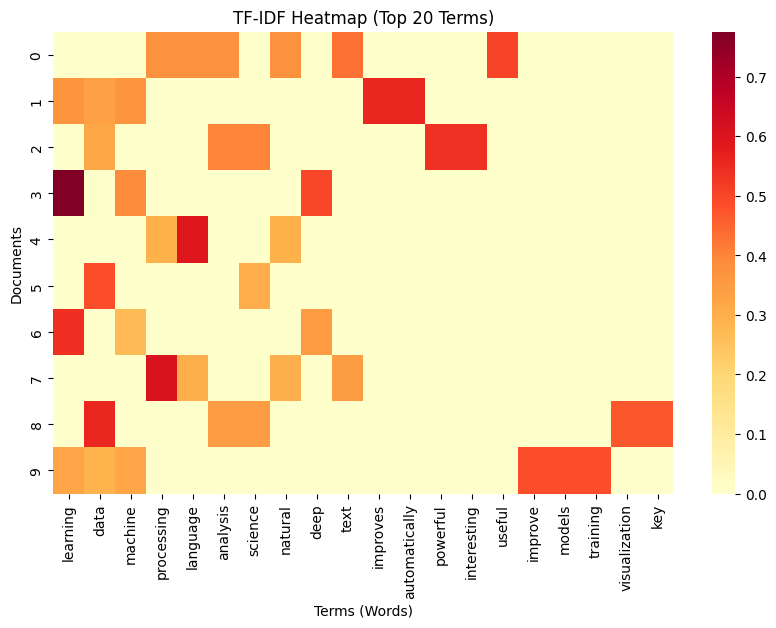

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 20 important terms (features)
top_terms = tfidf_df.mean().sort_values(ascending=False).head(20).index

# Create subset of TF-IDF DataFrame with only top terms
tfidf_top = tfidf_df[top_terms]

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    tfidf_top,
    annot=False,        # No numbers inside boxes (keeps it clean)
    cmap='YlOrRd',      # Color scheme (yellow → red)
    cbar=True           # Show color scale
)

# Add labels and title
plt.title('TF-IDF Heatmap (Top 20 Terms)')
plt.xlabel('Terms (Words)')
plt.ylabel('Documents')

plt.show()
# This heatmap visualizes TF-IDF scores of top 20 terms across all documents.
# Each row represents a document and each column represents a word.
# Darker colors indicate higher importance of a word in a document.

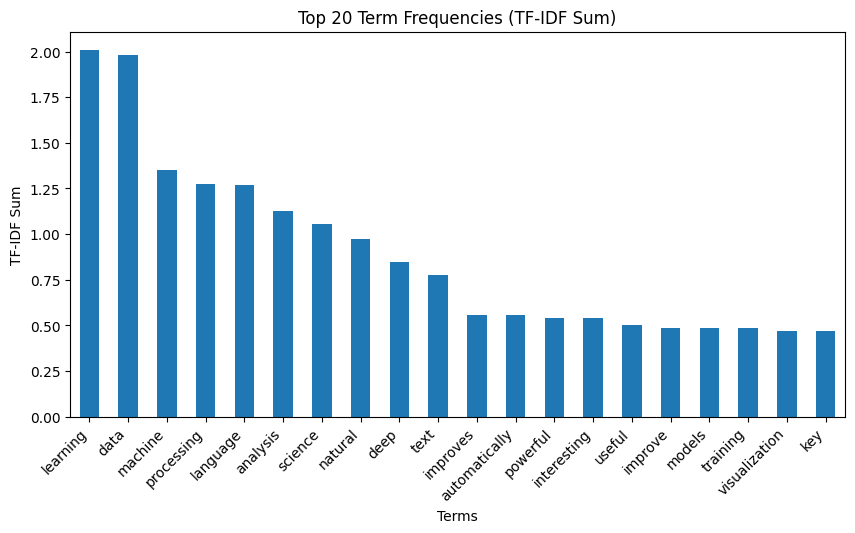

In [ ]:
# Term frequency analysis
term_frequencies = tfidf_df.sum(axis=0).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
term_frequencies.head(20).plot(kind='bar')
plt.title('Top 20 Term Frequencies (TF-IDF Sum)')
plt.xlabel('Terms')
plt.ylabel('TF-IDF Sum')
plt.xticks(rotation=45, ha='right')
plt.show()
# It helps identify which words are most significant in the dataset.
# Higher TF-IDF values indicate more important words.